In [ ]:
import SignalRate_8p_osc as s2d   # with oscillation
# import SignalRate_8p as s2d     # without oscillation (comment this line if you want to use the oscillation version)
osc = True  # Set to True for oscillation, False for no oscillation 
path_sample = r'./Data/samples_HK_osc.npy' if osc else r'./Data/samples_HK.npy'

import numpy as np
from scipy.optimize import minimize
import definition as df
from Simulation_Spectrum import time_limit

path_ret_osc = r'./Data/m_lambda_space_2d_osc_test.npy' 
path_ret = r'./Data/m_lambda_space_2d_test.npy'

precision = 64
E_range = (5, 50)
t_range = (0.01, time_limit('max'))

E_min, E_max = E_range
t_min, t_max = t_range

range_k = [t_range, E_range,  (-1, 1)]

def SR_HK(t, E_e, c, *args):

    R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu = args

    # N_K = 1.43e32 # for K-II

    N_K = 1.26e34 # for HK

    # eff_K = 0.932/np.sqrt(1+(34/(12-7*E_e+E_e**2))**2)        # This one is not well-fitted

    eff_K = 1

    ret = N_K * s2d.cs_at_c(c, s2d.E_nu(E_e, c)) * s2d.Flux_total(t, s2d.E_nu(E_e, c), R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu) * s2d.E_nu_at_E_e(E_e, c) * eff_K

    if osc: # To make the sample size comparable with the non-oscillation case
            k = 1994/1784   # calculated before
            ret = k * ret
    
    return ret


params = [15, 5, 5, 0.5, 2, 0.5, -4, -16]    # null hypothesis parameters for the flux function

if osc:
    print("Running with oscillation effects. Make sure to import SignalRate_2d_osc as s2d.")
else:
    print("Running without oscillation effects. Make sure to import SignalRate_2d as s2d.")

Running with oscillation effects. Make sure to import SignalRate_2d_osc as s2d.


In [15]:
# sample simlulation

def minimize_sr(vars):
    t, E = vars
    return - SR_HK(t, E, 0,*params)

ret = minimize(minimize_sr, x0=[0.1, 10], bounds=(t_range, E_range), method='L-BFGS-B')

print('f_max and coordinates', -ret.fun, ret.x)

f_max = -ret.fun
num_samples = df.gl3_integrate(SR_HK, range_k, precision, args=params)
print('num_samples', num_samples)


f_max and coordinates 80.39810857213743 [1.0000000e-02 1.1028937e+01]
num_samples 1813.6549488817363


In [9]:

def sample_rejection(flux_func, E_range, t_range, f_max, num_samples, *args):
    samples = []
    
    while len(samples) < num_samples:
        # 1. Propose E and t uniformly within your bounds
        E_prop = np.random.uniform(E_range[0], E_range[1])
        t_prop = np.random.uniform(t_range[0], t_range[1])
        
        # 2. Draw a uniform height to test against the flux
        u = np.random.uniform(0, f_max)
        
        # 3. Accept if the test height is under the distribution surface
        if u < flux_func(t_prop, E_prop, 0, *args):
            samples.append((t_prop, E_prop))
            
    return np.array(samples)

t_samples, E_samples = sample_rejection(SR_HK, E_range, t_range, f_max, num_samples, *params).T

np.save(path_sample, np.array([t_samples, E_samples]).T)

In [ ]:
import numpy as np
import definition as df
from scipy.integrate import quad_vec

E_min, E_max = E_range
t_min, t_max = t_range

t_samples = np.load(path_sample)[:, 0]
E_samples = np.load(path_sample)[:, 1]

print('sample shape', t_samples.shape, E_samples.shape)

range_k = [t_range, E_range,  (-1, 1)]

def param_set(log_m, log_lambda):
    return [15, 5, 5, 0.5, 2, 0.5, log_m, log_lambda]

def log_likelihood(log_m, log_lambda):

    fun1_K = lambda x: SR_HK(t_samples, x, 0, *param_set(log_m, log_lambda))

    part1_K = df.gl3_integrate(SR_HK, range_k, precision, args=param_set(log_m, log_lambda))

    part2_K = df.gl_integrate(fun1_K, E_min, E_max, precision=64)

    # part2_K, error_est = quad_vec(fun1_K, E_min, E_max)

    part3_K = 1e-4

    ret_K = -part1_K + np.sum(np.log(part3_K + part2_K))

    return ret_K

def chi_2(log_m, log_lambda):
    return -2 * log_likelihood(log_m, log_lambda)

# print('baseline:', chi_2(-4, -12))
print('this one must be positive, if not, check whether the right data is used')
print('assume:', chi_2(2, -5.8) - chi_2(-4, -16))

print('benchmark:', log_likelihood(-4, -16))
print('assume:', log_likelihood(2, -6.8))

sample shape (1623,) (1623,)
this one must be positive, if not, check whether the right data is used
assume: 1526.927343326006
benchmark: 7096.9306928972055
assume: 6333.467021234203


In [4]:
import numpy as np
from scipy.optimize import minimize, root_scalar

log_m_vals = np.linspace(2.45, 3, 50)
log_lambda_95CL = []

for log_m in log_m_vals:

    best_log_lambda = -10
    chi2_min = chi_2(-4, -16)
    # this is the benchmark of minimum chi_2

    upper_bracket = best_log_lambda + 7  # Adjust if you expect the limit to be higher than this.

    target_chi2 = chi2_min + 3.84
    
    def root_func(l_lambda):
        return chi_2(log_m, l_lambda) - target_chi2
        
    try:
        res_root = root_scalar(root_func, bracket=[best_log_lambda, upper_bracket], method='brentq')
        print('best_log_lambda', best_log_lambda, 'log_m:', log_m, 'log_lambda:', res_root.root)
        log_lambda_95CL.append(res_root.root)
        
    except ValueError:
        print('best_log_lambda', best_log_lambda)
        print(f"Failed to bracket root at log_m = {log_m}. Check the bracket range.")
        log_lambda_95CL.append(np.nan)


log_lambda_95CL = np.array(log_lambda_95CL)
print(log_lambda_95CL)

if osc:
    np.save(path_ret_osc, np.array([log_m_vals, log_lambda_95CL]).T)
else:
    np.save(path_ret, np.array([log_m_vals, log_lambda_95CL]).T)

best_log_lambda -10 log_m: 2.45 log_lambda: -8.43154386480726
best_log_lambda -10 log_m: 2.4612244897959186 log_lambda: -8.455507760690868
best_log_lambda -10 log_m: 2.472448979591837 log_lambda: -8.467189329187926
best_log_lambda -10 log_m: 2.4836734693877554 log_lambda: -8.47804618118954
best_log_lambda -10 log_m: 2.4948979591836737 log_lambda: -8.488376025206001
best_log_lambda -10 log_m: 2.506122448979592 log_lambda: -8.49288464216295
best_log_lambda -10 log_m: 2.5173469387755105 log_lambda: -8.496141207748916
best_log_lambda -10 log_m: 2.528571428571429 log_lambda: -8.570872553636503
best_log_lambda -10 log_m: 2.5397959183673473 log_lambda: -8.738457291954125
best_log_lambda -10 log_m: 2.5510204081632653 log_lambda: -8.845383217788088
best_log_lambda -10 log_m: 2.5622448979591836 log_lambda: -8.707691086194961
best_log_lambda -10 log_m: 2.573469387755102 log_lambda: -8.602103576328316
best_log_lambda -10 log_m: 2.5846938775510204 log_lambda: -8.644889933640227
best_log_lambda -10 

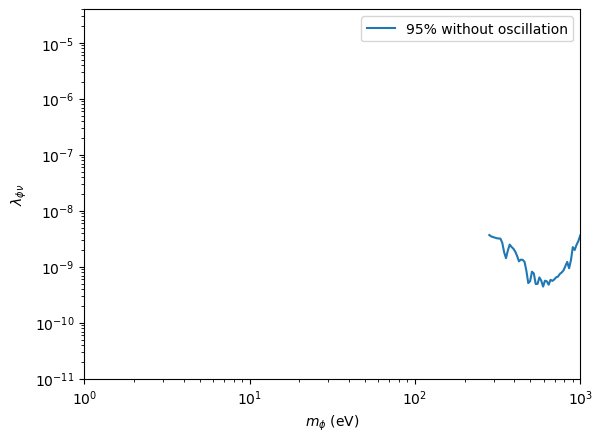

In [6]:
# only for plots

log_m_vals, log_lambda_95CL = np.load(path_ret_osc).T
# log_m_vals_osc, log_lambda_95CL_osc = np.load(path_ret_osc).T

%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(10**log_m_vals, 10**log_lambda_95CL, label='95% without oscillation')
# ax.plot(10**log_m_vals_osc, 10**log_lambda_95CL_osc, label='95% with oscillation', linestyle='--')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_{\phi}$ (eV)')
ax.set_ylabel(r'$\lambda_{\phi\nu}$')
ax.set_xlim(1, 1e3)
ax.set_ylim(1e-11, 4e-5)
ax.legend()

fig

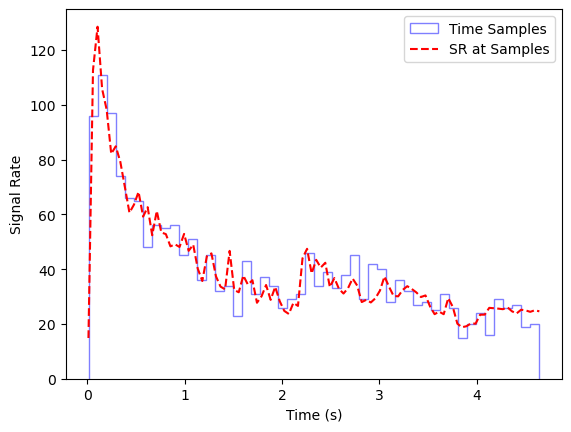

In [11]:
# obsolete, but still useful for testing the signal rate function

import numpy as np
import matplotlib.pyplot as plt
import definition as df
import SignalRate_2d as s2d
from Simulation_Spectrum import time_limit

t_range = (0.01, time_limit('max'))


t_samples = np.load(r'F:/Neutrino_SI/Data/samples_HK.npy')[:, 0]
E_samples = np.load(r'F:/Neutrino_SI/Data/samples_HK.npy')[:, 1]

def SR_HK(t, E_e, c, *args):

    R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu = args

    # N_K = 1.43e32 # for K-II

    N_K = 1.26e34 # for HK

    # eff_K = 0.932/np.sqrt(1+(34/(12-7*E_e+E_e**2))**2)        # This one is not well-fitted

    eff_K = 1

    ret = N_K * s2d.cs_at_c(c, s2d.E_nu(E_e, c)) * s2d.flux_2d(t, s2d.E_nu(E_e, c), R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu) * s2d.E_nu_at_E_e(E_e, c) * eff_K

    return ret

params_1 = [0, 0, 0, 0, 0, 0, -4, -12]
params_2 = [0, 0, 0, 0, 0, 0, 1.2244897959183674, -6.0228186190835595]
ranges: list = [(5, 50),  (-1, 1)]
bin_num = 50

integ_1 = lambda E, c, t: SR_HK(t, E, c, *params_1)
integ_2 = lambda E, c, t: SR_HK(t, E, c, *params_2)

t_space = np.linspace(t_range[0], t_range[1], 100)
y_1 = df.gl2_integrate_vec(integ_1, ranges, t_space)*t_range[1]/bin_num
# y_2 = df.gl2_integrate_vec(integ_2, ranges, t_space)*t_range[1]/bin_num

fig, ax = plt.subplots()
ax.hist(t_samples, bins=bin_num, alpha=0.5, label='Time Samples', color='blue', histtype = 'step')
ax.plot(t_space, y_1, label='SR at Samples', color = 'red', linestyle='--')
# ax.plot(t_space, y_2, label='SR at 95% CL', color = 'green', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Signal Rate')
plt.legend()

fig